# Seller Concentration & Prioritization

**Business question:** Which sellers deserve operational investigation first?

A seller can have a very high late rate but affect only a handful of orders. Another seller can have a moderate rate but create much more marketplace impact because of scale.

This notebook therefore separates three ideas:

1. **Concentration** — how much of the marketplace problem comes from a relatively small seller group?
2. **Rate vs. scale** — which sellers look bad because of rate, and which actually create material impact?
3. **Excess late orders** — which sellers produce more late orders than expected at the marketplace benchmark?
4. **Sensitivity** — does the candidate set survive a reasonable minimum-volume rule?

The SQL layer owns the metric definitions. Reconciliation and grain checks live in the automated tests; this notebook focuses on interpretation.


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from python.scripts.config import ANALYSIS_OUTPUT_DIR

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sellers = pd.read_csv(ANALYSIS_OUTPUT_DIR / "seller_prioritization.csv")
watch = pd.read_csv(ANALYSIS_OUTPUT_DIR / "seller_watchlist.csv")
sensitivity = pd.read_csv(
    ANALYSIS_OUTPUT_DIR / "seller_volume_threshold_sensitivity.csv"
)

eligible = sellers["delivery_eligible_seller_orders"]
late = sellers["late_seller_orders"]
marketplace_rate = sellers["marketplace_seller_late_rate"].iloc[0]

print(f"Sellers: {len(sellers):,}")
print(f"Eligible seller-orders: {eligible.sum():,.0f}")
print(f"Late seller-orders: {late.sum():,.0f}")
print(f"Marketplace seller-order late rate: {marketplace_rate:.2%}")
print(f"Candidate watchlist: {len(watch):,} sellers")


Sellers: 3,095
Eligible seller-orders: 97,811
Late seller-orders: 6,547
Marketplace seller-order late rate: 6.69%
Candidate watchlist: 25 sellers


## 1. How concentrated is the problem?

Contribution answers a different question from late rate:

> **Of all late seller-orders in the marketplace, how many came from each seller?**

The Pareto view shows whether Operations is facing a broad marketplace problem or a problem concentrated among a manageable subset of sellers.


,Target share of late units,Sellers required,Share of sellers with late orders
0,50%,98,0.077
1,80%,398,0.312


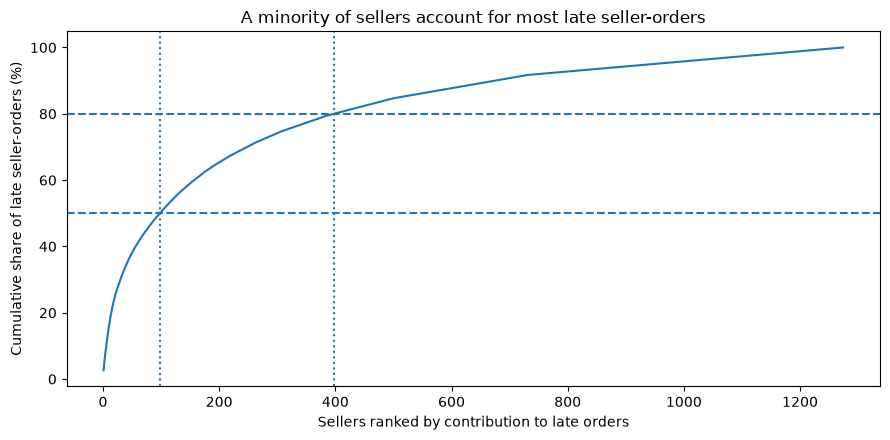

In [3]:
with_late = sellers[sellers["late_seller_orders"] > 0].sort_values(
    "contribution_row_number"
)

def sellers_to_reach(share):
    return int((with_late["cumulative_late_contribution"] < share).sum() + 1)

n50 = sellers_to_reach(0.50)
n80 = sellers_to_reach(0.80)

summary = pd.DataFrame(
    {
        "Target share of late units": ["50%", "80%"],
        "Sellers required": [n50, n80],
        "Share of sellers with late orders": [
            n50 / len(with_late),
            n80 / len(with_late),
        ],
    }
)
display(summary)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    range(1, len(with_late) + 1),
    with_late["cumulative_late_contribution"] * 100,
)
ax.axhline(50, linestyle="--")
ax.axhline(80, linestyle="--")
ax.axvline(n50, linestyle=":")
ax.axvline(n80, linestyle=":")
ax.set(
    title="A minority of sellers account for most late seller-orders",
    xlabel="Sellers ranked by contribution to late orders",
    ylabel="Cumulative share of late seller-orders (%)",
)
fig.tight_layout()
plt.show()


## 2. Why is late rate alone misleading?

Small sellers can easily post extreme percentages. A 100% late rate on one eligible order is operationally very different from a 10% late rate across thousands of orders.

Plotting **late rate against eligible volume** makes that distinction visible. The horizontal line is the marketplace benchmark; the highlighted sellers are the candidate watchlist.


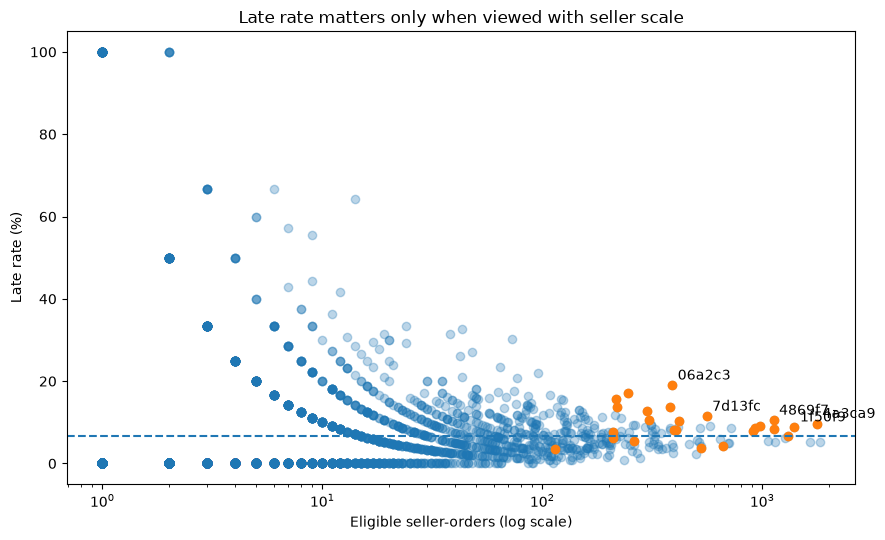

In [4]:
data = sellers[eligible > 0].copy()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(
    data["delivery_eligible_seller_orders"],
    data["seller_late_rate"] * 100,
    alpha=0.30,
)

highlight = data[data["seller_id"].isin(watch["seller_id"])]
ax.scatter(
    highlight["delivery_eligible_seller_orders"],
    highlight["seller_late_rate"] * 100,
)

for row in highlight.nlargest(5, "excess_late_marketplace").itertuples():
    ax.annotate(
        row.seller_id[:6],
        (row.delivery_eligible_seller_orders, row.seller_late_rate * 100),
        xytext=(4, 4),
        textcoords="offset points",
    )

ax.axhline(marketplace_rate * 100, linestyle="--")
ax.set_xscale("log")
ax.set(
    title="Late rate matters only when viewed with seller scale",
    xlabel="Eligible seller-orders (log scale)",
    ylabel="Late rate (%)",
)
fig.tight_layout()
plt.show()


## 3. Which sellers generate the most excess late orders?

To combine performance and scale, use a simple benchmark:

```text
expected late = eligible seller-orders × marketplace late rate
excess late   = observed late seller-orders − expected late
```

A positive excess means the seller produced more late seller-orders than expected if it performed at the marketplace rate.

This is not a causal estimate or an intervention score. It is a transparent prioritization measure.


,seller_id,delivery_eligible_seller_orders,late_seller_orders,seller_late_rate,expected_late_marketplace,excess_late_marketplace,seller_late_contribution,seller_late_gmv
0,4a3ca9315b744ce9f8e9374361493884,1772,172,0.097,118.609,53.391,0.026,"20,063.190"
10,06a2c3af7b3aee5d69171b0e14f0ee87,389,74,0.190,26.038,47.962,0.011,"6,564.220"
2,4869f7a5dfa277a7dca6462dcf3b52b2,1124,118,0.105,75.235,42.765,0.018,"24,509.200"
1,1f50f920176fa81dab994f9023523100,1399,124,0.089,93.642,30.358,0.019,"8,250.300"
12,7d13fca15225358621be4086e1eb0964,558,64,0.115,37.350,26.650,0.010,"14,042.440"
17,8160255418d5aaa7dbdc9f4c64ebda44,380,52,0.137,25.435,26.565,0.008,"6,924.600"
20,88460e8ebdecbfecb5f9601833981930,246,42,0.171,16.466,25.534,0.006,"6,179.550"
5,7c67e1448b00f6e969d365cea6b010ab,973,89,0.091,65.128,23.872,0.014,"16,506.170"
4,ea8482cd71df3c1969d7b9473ff13abc,1132,96,0.085,75.771,20.229,0.015,"2,993.740"
26,e5a3438891c0bfdb9394643f95273d8e,216,34,0.157,14.458,19.542,0.005,"1,143.600"


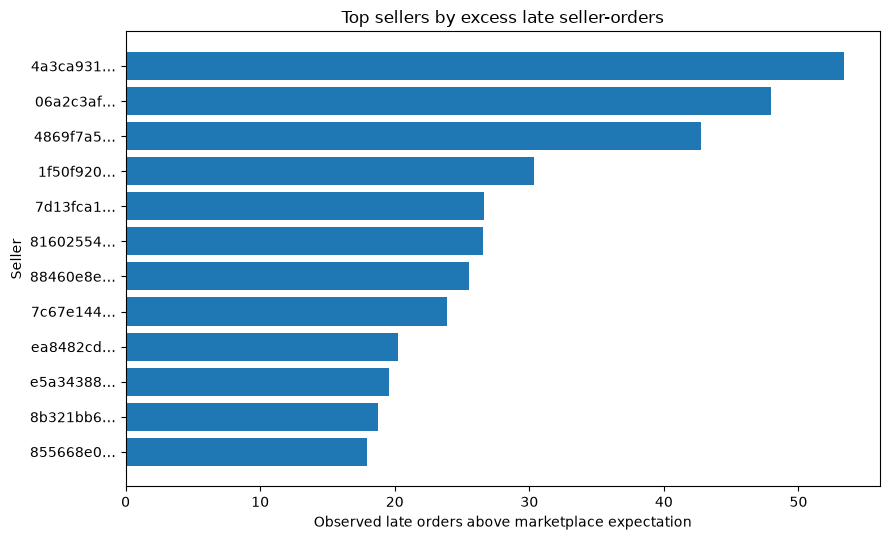

In [5]:
top = (
    sellers[sellers["delivery_eligible_seller_orders"] >= 100]
    .nlargest(12, "excess_late_marketplace")
    .copy()
)

display(
    top[
        [
            "seller_id",
            "delivery_eligible_seller_orders",
            "late_seller_orders",
            "seller_late_rate",
            "expected_late_marketplace",
            "excess_late_marketplace",
            "seller_late_contribution",
            "seller_late_gmv",
        ]
    ]
)

plot = top.sort_values("excess_late_marketplace")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(
    [seller[:8] + "…" for seller in plot["seller_id"]],
    plot["excess_late_marketplace"],
)
ax.set(
    title="Top sellers by excess late seller-orders",
    xlabel="Observed late orders above marketplace expectation",
    ylabel="Seller",
)
fig.tight_layout()
plt.show()


## 4. Does the prioritization depend on the volume threshold?

A minimum-volume rule reduces noisy small-seller rates, but setting it too high can hide meaningful marketplace impact.

The sensitivity table shows the trade-off between **fewer sellers to review** and **late-order coverage retained**.


,min_eligible_seller_orders,sellers_at_or_above,late_seller_orders_kept,share_of_marketplace_late_units,sellers_with_excess_ge_15
0,1,2970,6547,1.000,15
1,10,1237,6145,0.939,15
2,30,627,5485,0.838,15
3,50,425,4982,0.761,15
4,100,210,3986,0.609,14
5,200,86,2946,0.450,14
6,300,56,2468,0.377,11


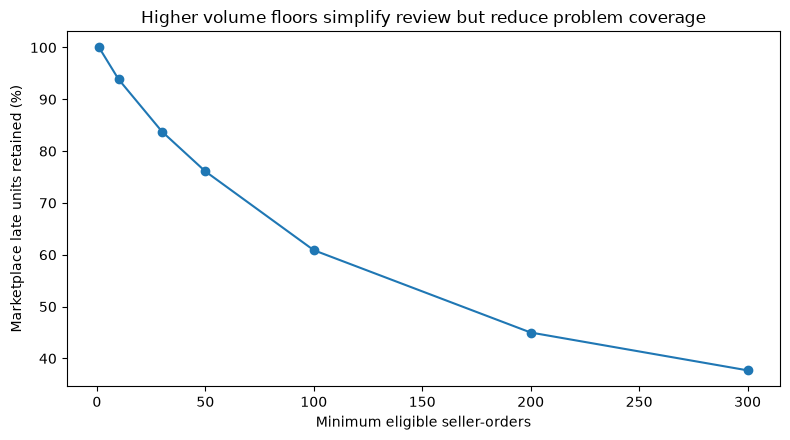

In [6]:
display(
    sensitivity[
        [
            "min_eligible_seller_orders",
            "sellers_at_or_above",
            "late_seller_orders_kept",
            "share_of_marketplace_late_units",
            "sellers_with_excess_ge_15",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    sensitivity["min_eligible_seller_orders"],
    sensitivity["share_of_marketplace_late_units"] * 100,
    marker="o",
)
ax.set(
    title="Higher volume floors simplify review but reduce problem coverage",
    xlabel="Minimum eligible seller-orders",
    ylabel="Marketplace late units retained (%)",
)
fig.tight_layout()
plt.show()


## Candidate watchlist

The watchlist is intentionally traceable. A seller enters because it meets at least one visible rule:

- high excess late orders;
- high late rate with meaningful volume;
- recent deterioration.

It is a **candidate investigation set**, not a remediation ranking.


In [7]:
watch_view = (
    watch.sort_values("excess_late_marketplace", ascending=False)
    [
        [
            "seller_id",
            "delivery_eligible_seller_orders",
            "late_seller_orders",
            "seller_late_rate",
            "seller_late_contribution",
            "excess_late_marketplace",
            "seller_late_gmv",
            "watchlist_reasons",
        ]
    ]
)

display(watch_view.head(15))

print(
    f"Watchlist covers "
    f"{watch['late_seller_orders'].sum() / sellers['late_seller_orders'].sum():.1%} "
    f"of marketplace late seller-orders."
)


,seller_id,delivery_eligible_seller_orders,late_seller_orders,seller_late_rate,seller_late_contribution,excess_late_marketplace,seller_late_gmv,watchlist_reasons
0,4a3ca9315b744ce9f8e9374361493884,1772,172,0.097,0.026,53.391,"20,063.190",high_excess_late; high_rate_high_volume; recen...
1,06a2c3af7b3aee5d69171b0e14f0ee87,389,74,0.190,0.011,47.962,"6,564.220",high_excess_late; high_rate_high_volume
2,4869f7a5dfa277a7dca6462dcf3b52b2,1124,118,0.105,0.018,42.765,"24,509.200",high_excess_late; high_rate_high_volume
3,1f50f920176fa81dab994f9023523100,1399,124,0.089,0.019,30.358,"8,250.300",high_excess_late
4,7d13fca15225358621be4086e1eb0964,558,64,0.115,0.010,26.650,"14,042.440",high_excess_late; high_rate_high_volume
5,8160255418d5aaa7dbdc9f4c64ebda44,380,52,0.137,0.008,26.565,"6,924.600",high_excess_late; high_rate_high_volume
6,88460e8ebdecbfecb5f9601833981930,246,42,0.171,0.006,25.534,"6,179.550",high_excess_late; high_rate_high_volume
7,7c67e1448b00f6e969d365cea6b010ab,973,89,0.091,0.014,23.872,"16,506.170",high_excess_late
8,ea8482cd71df3c1969d7b9473ff13abc,1132,96,0.085,0.015,20.229,"2,993.740",high_excess_late
9,e5a3438891c0bfdb9394643f95273d8e,216,34,0.157,0.005,19.542,"1,143.600",high_excess_late; high_rate_high_volume


Watchlist covers 21.5% of marketplace late seller-orders.


## Takeaways

- **Late rate and marketplace impact are not the same thing.** Very high rates are common among tiny sellers, so rate alone is a poor prioritization rule.
- **The problem is concentrated enough to prioritize.** A subset of sellers accounts for a large share of marketplace late seller-orders.
- **Excess late orders provide a simple rate-and-scale measure.** They identify sellers producing more late orders than expected under a transparent marketplace benchmark.
- **Volume thresholds create a real trade-off.** Raising the minimum volume reduces noise and review workload but also removes some late-order coverage.
- **The watchlist is a starting point for investigation.** Final intervention decisions should incorporate customer impact, statistical uncertainty, and operational context rather than a single seller score.
